In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("C:\AIML\Projects\Real Estate Investment Advisor\cleaned_data.csv")
df.head()

,State,City,Locality,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,...,Clubhouse,Garden,Gym,Playground,Pool,Availability_Status_Ready_to_Move,Availability_Status_Under_Construction,Total_Amenities,Amenity Density Score,Good_Investment
0,15,6,483,1,4740,48976000.0,10000.0,1990,22,1,...,1,1,1,1,1,1,0,5,19,0
1,11,33,434,3,2364,19552000.0,8000.0,2008,21,20,...,1,1,1,1,1,0,1,5,14,0
2,13,25,75,2,3642,18379000.0,5000.0,1997,19,27,...,1,0,1,1,1,1,0,4,21,0
3,14,21,326,2,2741,30029000.0,11000.0,1991,21,26,...,1,1,1,1,1,1,0,5,18,0
4,14,19,407,4,4823,18290000.0,4000.0,2002,3,2,...,1,1,1,1,1,1,0,5,18,1


Classification Model: Logistic Regression, Random Forest, or XGBoost Classifier etc. (at least 5)

 Target: Good_Investment


🔹Classification: Good Investment
Goal: Decide if property is worth buying.
Price vs Median: Price ≤ median → good investment


Price per Sq Ft: Cheaper than median → good


Multi-factor Score: Combine features (BHK≥3, RERA, ready-to-move) → threshold = good

In [5]:
median_ppsf=df['Price_per_SqFt'].mean()
median_amenity=df['Amenity Density Score'].mean()
df['Good_Investment']=(
    (df['Price_per_SqFt'] <= median_ppsf) &
    
    (df['BHK'] >= 3) &
    (df['Amenity Density Score'] >= median_amenity)
).astype(int)

In [6]:
print(df['Good_Investment'].isna().sum())

0


In [7]:
df['Good_Investment'].value_counts()

Good_Investment
0    193970
1     56030
Name: count, dtype: int64

In [8]:
X=df.drop([
    'Good_Investment',
    'Price_per_SqFt',
    'BHK',
    'Amenity Density Score'],axis=1)
y=df['Good_Investment']

In [9]:
df = df.dropna(subset=['Good_Investment'])

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [12]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

200000
50000
200000
50000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [14]:
with open("classification_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

m1=LogisticRegression(max_iter=1000,class_weight='balanced')
m1.fit(X_train, y_train)

y_pred = m1.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report,f1_score,confusion_matrix

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.76598
Classification report:               precision    recall  f1-score   support

           0       0.93      0.76      0.83     38900
           1       0.48      0.79      0.60     11100

    accuracy                           0.77     50000
   macro avg       0.71      0.78      0.72     50000
weighted avg       0.83      0.77      0.78     50000

F1 Score: 0.6010433359473558


Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

m2=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
m2.fit(X_train, y_train)

y_pred = m2.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report,f1_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.80338
Classification report:               precision    recall  f1-score   support

           0       0.84      0.93      0.88     38900
           1       0.59      0.37      0.45     11100

    accuracy                           0.80     50000
   macro avg       0.71      0.65      0.67     50000
weighted avg       0.78      0.80      0.79     50000

F1 Score: 0.45343859454050145


In [17]:
print(len(X_test))
print(len(y_test))
print(len(y_pred))

50000
50000
50000


Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

m3=GradientBoostingClassifier()
m3.fit(X_train, y_train)

y_pred = m3.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, classification_report,f1_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.81932
Classification report:               precision    recall  f1-score   support

           0       0.88      0.89      0.88     38900
           1       0.60      0.58      0.59     11100

    accuracy                           0.82     50000
   macro avg       0.74      0.73      0.74     50000
weighted avg       0.82      0.82      0.82     50000

F1 Score: 0.5870737727397386


In [20]:
print(len(X_test))
print(len(y_test))
print(len(y_pred))
print(len(X_train))
print(len(y_train))

50000
50000
50000
200000
200000


XGBoost

In [21]:
from xgboost import XGBClassifier

m4=XGBClassifier(scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),use_label_encoder=False, eval_metric='logloss',class_weight='balanced')
m4.fit(X_train, y_train)

y_pred = m4.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report,f1_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.84512
Classification report:               precision    recall  f1-score   support

           0       0.99      0.81      0.89     38900
           1       0.59      0.98      0.74     11100

    accuracy                           0.85     50000
   macro avg       0.79      0.89      0.81     50000
weighted avg       0.90      0.85      0.86     50000

F1 Score: 0.7383607000473005


In [23]:
import pickle
with open("classification.pkl", "wb") as f:
    pickle.dump(m4, f)

KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier

m5 = KNeighborsClassifier()
m5.fit(X_train, y_train)

y_pred = m5.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report,f1_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.77688
Classification report:               precision    recall  f1-score   support

           0       0.82      0.91      0.86     38900
           1       0.50      0.31      0.38     11100

    accuracy                           0.78     50000
   macro avg       0.66      0.61      0.62     50000
weighted avg       0.75      0.78      0.76     50000

F1 Score: 0.38200753379126967


EDA


Impact of crime rate on good investment classification

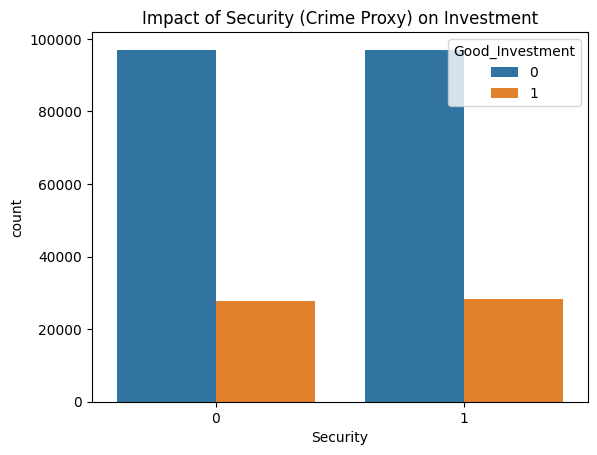

In [26]:
import seaborn as sns

sns.countplot(x='Security',hue='Good_Investment',data=df)
plt.title("Impact of Security (Crime Proxy) on Investment")
plt.show()

In [27]:
import pickle 

pickle.dump 
#create pickle file
pickle.load
# Using the pickle file 

<function _pickle.load(file, *, fix_imports=True, encoding='ASCII', errors='strict', buffers=())>

In [32]:
features = df.drop("Good_Investment", axis=1).columns[:len(model.feature_importances_)]

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20))

                              Feature  Importance
9                        Total_Floors    0.230142
10                    Age_of_Property    0.218384
4                        Size_in_SqFt    0.120961
30  Availability_Status_Ready_to_Move    0.114499
3                                 BHK    0.107553
11                     Nearby_Schools    0.060457
26                             Garden    0.007283
25                          Clubhouse    0.007218
17                             Facing    0.007188
23    Furnished_Status_Semi-furnished    0.007116
24       Furnished_Status_Unfurnished    0.006825
0                               State    0.006666
7                          Year_Built    0.006592
2                            Locality    0.006500
14                      Parking_Space    0.006487
5                      Price_in_Lakhs    0.006468
15                           Security    0.006418
27                                Gym    0.006356
13     Public_Transport_Accessibility    0.006353
